In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')


In [4]:
print("Shape:", df.shape)
print(df.info())

Shape: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


In [5]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


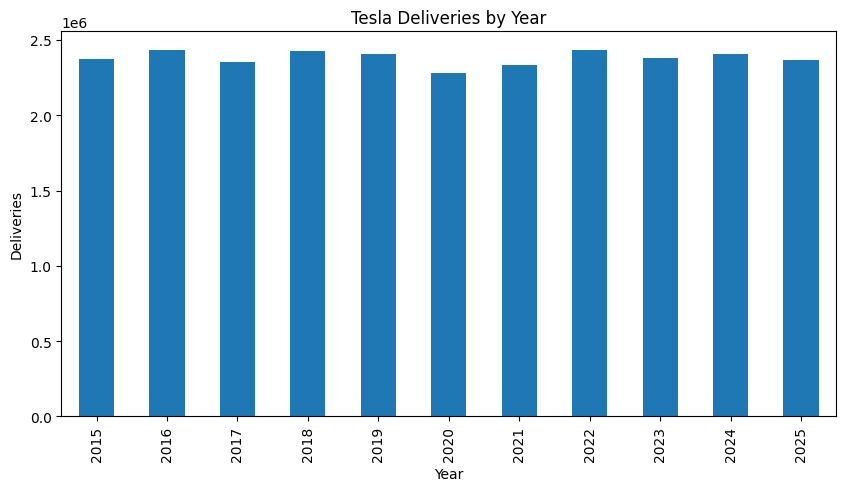

In [7]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
yearly.plot(kind='bar')
plt.title('Tesla Deliveries by Year')
plt.ylabel('Deliveries')
plt.show()

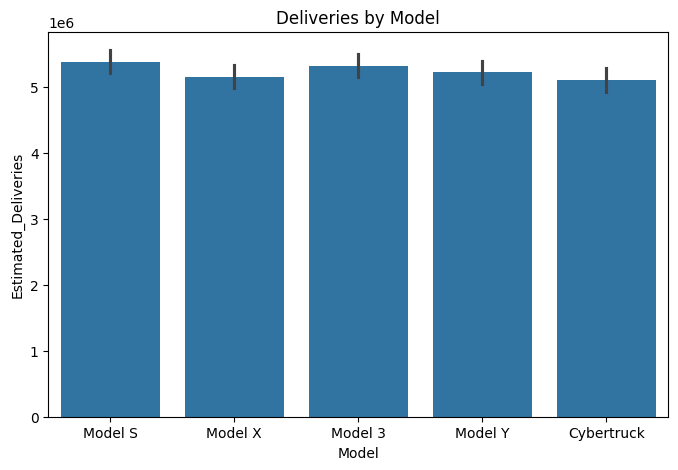

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries',
    estimator=sum
)

plt.title('Deliveries by Model')
plt.show()

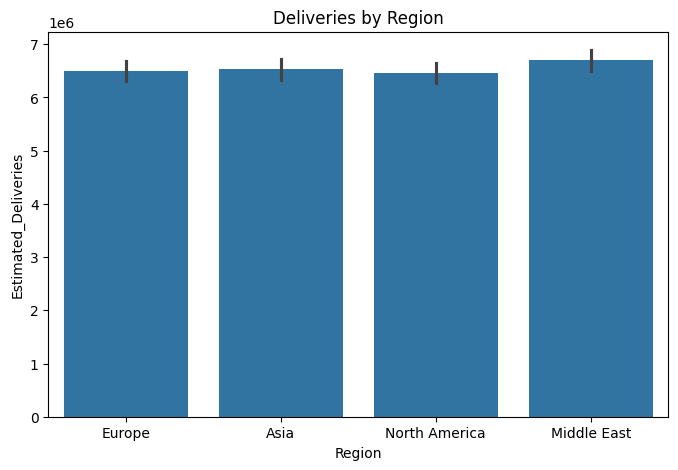

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries',
    estimator=sum
)

plt.title('Deliveries by Region')
plt.show()

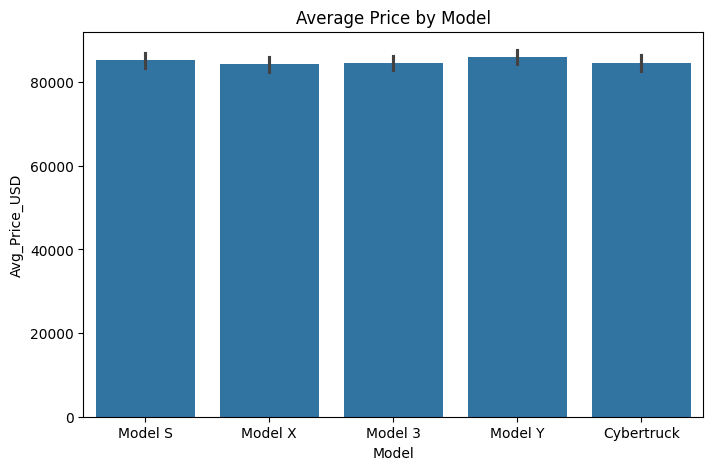

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Model',
    y='Avg_Price_USD'
)

plt.title('Average Price by Model')
plt.show()

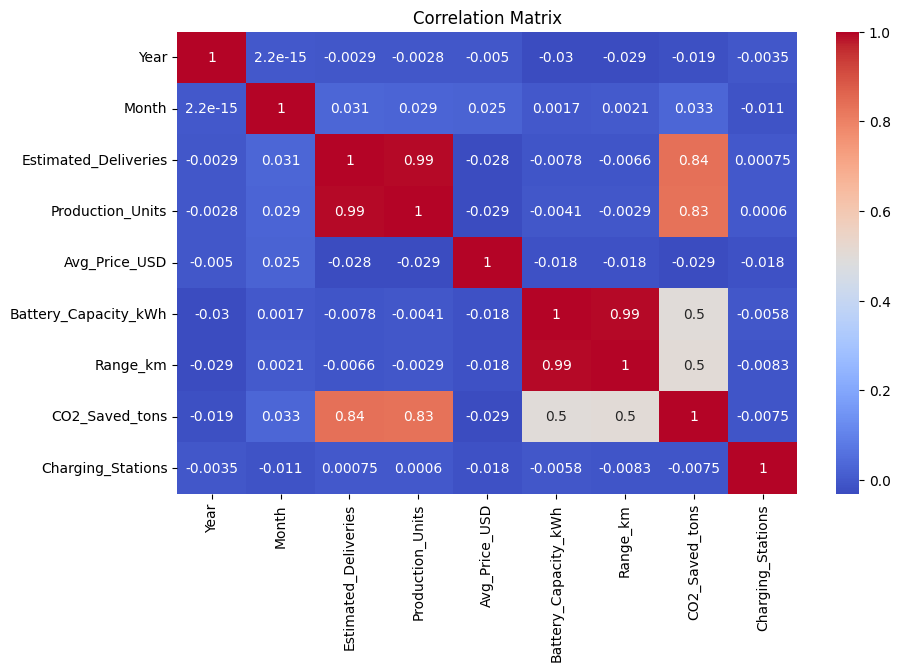

In [11]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

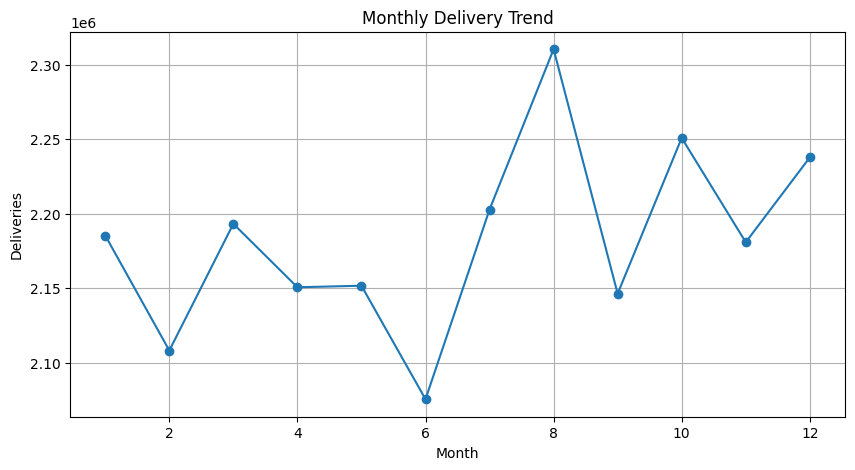

In [12]:
monthly = df.groupby('Month')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
monthly.plot(marker='o')

plt.title('Monthly Delivery Trend')
plt.ylabel('Deliveries')
plt.grid(True)

plt.show()

In [13]:
top10 = df.sort_values(
    by='Estimated_Deliveries',
    ascending=False
).head(10)

top10

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
1341,2017,12,North America,Model 3,25704,28939,61247.57,120,661,2548.55,Official (Quarter),8388
281,2015,3,Asia,Model 3,25410,28802,73659.66,60,341,1299.72,Official (Quarter),4127
725,2015,6,Middle East,Model Y,22315,22673,81318.87,82,472,1579.90,Interpolated (Month),5909
2490,2022,5,Europe,Model Y,21772,23530,89555.17,60,358,1169.16,Official (Quarter),13826
729,2018,4,Europe,Model X,21473,24427,78461.34,60,334,1075.80,Interpolated (Month),11576
117,2022,11,Middle East,Model Y,21296,23581,57673.97,60,352,1124.43,Estimated (Region),4630
206,2022,10,Europe,Model 3,20841,23735,95174.19,60,342,1069.14,Official (Quarter),14164
2142,2022,1,North America,Model S,20667,23519,53441.10,82,474,1469.42,Interpolated (Month),13243
2092,2016,12,Asia,Model S,20577,21279,117482.02,120,714,2203.80,Official (Quarter),11665
1456,2021,2,North America,Model X,20568,22879,117528.33,120,664,2048.57,Interpolated (Month),3641
